In [ ]:
using ITensors, ITensorMPS, ProgressMeter, Plots, LinearAlgebra

include("main.jl")

: 

In [2]:
# Parameters to sweep
L_values = [16, 32, 64]
beta_values = vcat(
    range(0.3, stop=0.4, length=2),
    range(0.41, stop=0.48, length=4),
    range(0.5, stop=0.6, length=2)
)

D_bound = 2
N_samples = 2000 

# Dictionaries to store results
results_acc = Dict(L => Float64[] for L in L_values)
results_e = Dict(L => Float64[] for L in L_values)

Dict{Int64, Vector{Float64}} with 3 entries:
  32 => []
  64 => []
  16 => []

In [3]:
println("Starting Phase Transition Sweep for D_bound=$D_bound")
println("Betas: ", beta_values)

for L in L_values
    println("\n--- Running for Grid $(L)x$(L) ---")
    
    @showprogress "L=$L Sweep: " for beta in beta_values
        acc, e = run_mcmc_sweep(L, L, beta, D_bound, N_samples)
        push!(results_acc[L], acc)
        push!(results_e[L], e)
    end
end

Starting Phase Transition Sweep for D_bound=2
Betas: [0.3, 0.4, 0.41, 0.43333333333333335, 0.45666666666666667, 0.48, 0.5, 0.6]

--- Running for Grid 16x16 ---


L=16 Sweep: 100%|███████████████████████████████████████| Time: 0:35:06



--- Running for Grid 32x32 ---


L=32 Sweep: 100%|███████████████████████████████████████| Time: 2:29:24



--- Running for Grid 64x64 ---


L=64 Sweep: 100%|███████████████████████████████████████| Time: 10:58:04


In [13]:
using JLD2

output_file = "ising_mcmc_results_D$(D_bound).jld2"

jldsave(output_file; 
    results_acc = results_acc,
    results_e = results_e,
    beta_values = beta_values,
    L_values = L_values,
    D_bound = D_bound,
    N_samples = N_samples
)

In [15]:
pwd()

"/home/jmarquezol/.local/share/Trash/files/jl/icfo_intern"

In [10]:
using JLD2

filename = "ising_mcmc_results_D2.jld2"

@load filename results_acc results_e beta_values L_values D_bound N_samples

6-element Vector{Symbol}:
 :results_acc
 :results_e
 :beta_values
 :L_values
 :D_bound
 :N_samples

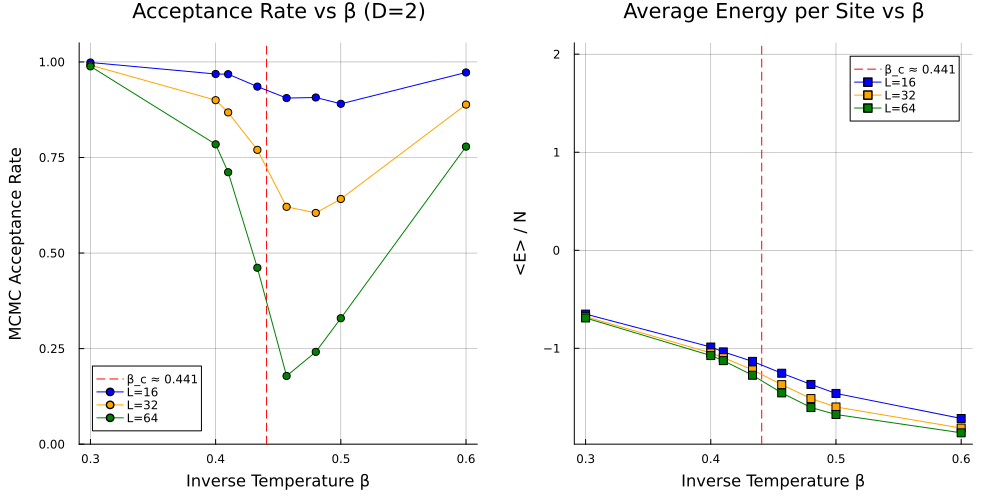

In [7]:
# PLOTTING
beta_c_analytical = log(1 + sqrt(2)) / 2  # ~ 0.44068

p1 = plot(title="Acceptance Rate vs β (D=$D_bound)", xlabel="Inverse Temperature β", ylabel="MCMC Acceptance Rate", ylims=(0, 1.05), grid=true, gridalpha=0.4, legend=:bottomleft)
p2 = plot(title="Average Energy per Site vs β", xlabel="Inverse Temperature β", ylabel="<E> / N", grid=true, gridalpha=0.4, legend=:topright)

# Analytical critical lines
vline!(p1, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")
vline!(p2, [beta_c_analytical], color=:red, linestyle=:dash, label="β_c ≈ 0.441")

colors = [:blue, :orange, :green]

# Plot the data
for (idx, L) in enumerate(L_values)
    plot!(p1, beta_values, results_acc[L], marker=:circle, color=colors[idx], label="L=$L")
    plot!(p2, beta_values, results_e[L], marker=:square, color=colors[idx], label="L=$L")
end

# Combine layouts side-by-side
plot(p1, p2, layout=(1, 2), size=(1000, 500), margin=5Plots.mm)

---

**Open problem: Mixing Times in Collective Updates**

The Tensor Network Metropolis-Hastings (TNMH) algorithm circumvents the diffusive random-walk behavior of local MCMC methods (like single-spin flip) by proposing global, collective updates. Because the proposed state $y$ is generated from a tensor network approximation $\tilde{\pi}_D(y)$ that is entirely independent of the current state $x$, the TNMH is classified mathematically as an Independent Metropolis-Hastings (IMH) sampler.

The correlation time $\tau_{corr}$ of an IMH sampler does not depend on local transition dynamics; it depends strictly on the structural overlap between the exact target distribution $\pi$ and the proposal distribution $\tilde{\pi}_D$. The objective of this research is to rigorously bound $\tau_{corr}$ as a function of the tensor network bond dimension $D$.

For an Independent Metropolis-Hastings chain, the Mengersen-Tweedie Theorem (Uniform Ergodicity) states that if there exists a finite constant $C \ge 1$ such that the ratio of the true weight to the proposal weight is bounded for all possible configurations $x$:

$$\max_{x} \frac{\pi(x)}{\tilde{\pi}_D(x)} \le C$$

Then the Markov chain possesses the following rigorous guarantees:
1. Spectral Gap: The spectral gap $\gamma$ is bounded by $\gamma \ge 1/C$.
2. Correlation Time: The mixing time is strictly bounded by $\tau_{corr} \le C$.
3. Coupling From The Past (CFTP): A perfect, burn-in-free sample can be achieved, with the probability of all parallel chains coupling in a single step being at least $1/C$.

To computationally prove the existence of $C$, we must map the additive error of the Singular Value Decomposition (SVD) truncation to the multiplicative error required by the Mengersen-Tweedie bound.

Evaluating the exact distribution $\pi(x)$ for a large 2D lattice is intractable. However, by restricting the lattice to a quasi-1D strip of width $L_y = 8$, the maximum possible entanglement across a horizontal cut requires a bond dimension of exactly $2^{L_y/2} = 16$. This permits the exact, lossless contraction of the environment $|E_{exact}\rangle$.

We evaluate the network layer-by-layer (row-by-row), maintaining two parallel universes:
- The Exact Universe: Truncated at $D=16$ (Lossless).
- The TNMH Universe: Truncated at $D_{bound} = 2$ (Approximation).

At each row $x$, we measure two distinct metrics:
- Fidelity (Additive Error): The Euclidean overlap $|\langle E_{exact} | E_{trunc} \rangle|$.
- The Mengersen-Tweedie Ratio (Multiplicative Error): By exhausting all $2^8 = 256$ physical spin configurations at the boundary, we project the physical states $\langle \psi_i |$ onto both environments to find the absolute worst-case divergence:

$$C_x = \max_{i \in \{1..256\}} \frac{\langle \psi_i | E_{exact} \rangle}{\langle \psi_i | E_{trunc} \rangle}$$

By plotting $C_x$ as a function of the strip length, we can observe whether the tensor network truncation bounds the correlation time (a plateau in $C_x$) or fails to capture critical entanglement (a divergence in $C_x$).

In [2]:
function run_error_tracker(Lx::Int, beta::Float64, D_bound::Int; Ly::Int=8)
    # We fix Ly = 8 to keep simulation manageable 
        
    A, s_inds, v_inds = create_ising_peps(Lx, Ly, beta, 1.0) # generates 2D PEPS grid A conaining the Boltzmann weights
    b = [Index(2, "Site,b=$y") for y in 1:Ly]
    
    # 1. Create the exact and truncated bottom environments

    # we start at the bottom row
    tensors_Lx = ITensor[]
    for y in 1:Ly
        T_traced = A[Lx, y] * ITensor([1.0, 1.0], s_inds[Lx, y]) # trace out the the physical spin d.o.f.
        T_traced = replaceinds(T_traced, [v_inds[Lx-1, y]] => [b[y]]) # update upward-pointing vertical bond to dummy index b[y]
        push!(tensors_Lx, T_traced) # we get a 1D MPS boundary environment
    end
    
    # start envs as the exact same bottom row
    E_exact = MPS(tensors_Lx)
    E_trunc = MPS(tensors_Lx)
    
    # track the log normalizations
    log_Z_exact = 0.0
    log_Z_trunc = 0.0
    
    x_values = Int[]
    fidelities = Float64[]
    worst_case_ratios = Float64[]

    exact_maxdim = 2^(Ly) 
    
    # 2. Sweep env upwards row by row
    @showprogress for x in Lx-1:-1:2
        # Build the MPO for the current row
        tensors_mpo = ITensor[]
        for y in 1:Ly
            T_traced = A[x, y] * ITensor([1.0, 1.0], s_inds[x, y])
            T_traced = replaceinds(T_traced, [v_inds[x, y], v_inds[x-1, y]] => [b[y], b[y]'])
            push!(tensors_mpo, T_traced)
        end
        MPO_x = MPO(tensors_mpo)
                        
        # A. Exact
        E_exact = apply(MPO_x, E_exact; maxdim=exact_maxdim, cutoff=1e-16)
        E_exact = noprime(E_exact)
        
        # Sweep right-to-left to bound tensors 2-8, pushing magnitude to tensor 1
        orthogonalize!(E_exact, 1) # QR decomposition sweep
        n_exact = norm(E_exact[1])
        E_exact[1] ./= n_exact
        log_Z_exact += log(n_exact)
        
        # B. Truncated
        E_trunc = apply(MPO_x, E_trunc; maxdim=D_bound, cutoff=1e-10)
        E_trunc = noprime(E_trunc)
        
        # Sweep right-to-left to bound tensors 2-8, pushing magnitude to tensor 1
        orthogonalize!(E_trunc, 1)
        n_trunc = norm(E_trunc[1])
        E_trunc[1] ./= n_trunc
        log_Z_trunc += log(n_trunc)
        
        # 3. Measure addive error (Fidelity)
        fidelity = abs(inner(E_exact, E_trunc)) # how far apart are the two environments as vectors?
        push!(fidelities, fidelity)
        
        # 4. Measure multiplicative error (The Mengersen-Tweedie Bound)
        max_ratio_at_x = 0.0
        
        # loop over all 2^8 = 256 physical spin configs states of the top boundary
        for i in 0 : (2^Ly - 1)
            # Convert integer to binary spin array (0=Up, 1=Dn)
            spins = [(i >> (j - 1)) & 1 for j in 1:Ly] # array of 8 numbers (0s and 1s) representing our specific $\langle \psi_i |$
            
            row_tensors_exact = ITensor[]
            row_tensors_trunc = ITensor[]
            
            for y in 1:Ly
                T = A[x-1, y]
                
                # Project physical spin config onto the tensor T
                state_vec = spins[y] == 0 ? [1.0, 0.0] : [0.0, 1.0]
                T *= ITensor(state_vec, s_inds[x-1, y])
                
                # Trace out the upward vertical bond (if we are not at the absolute top row)
                if (x - 1) > 1
                    T *= ITensor([1.0, 1.0], v_inds[x-2, y])
                end
                
                # Contract with the respective bottom environments
                T_exact = T * replaceinds(E_exact[y], b[y] => v_inds[x-1, y])
                T_trunc = T * replaceinds(E_trunc[y], b[y] => v_inds[x-1, y])
                
                push!(row_tensors_exact, T_exact)
                push!(row_tensors_trunc, T_trunc)
            end
            
            # multiply the 8 tensors together (reduce(*, array) acts as a zipper) to collapse the horizontal bonds and extract the scalar raw probability
            prob_exact = abs(scalar(reduce(*, row_tensors_exact)))
            prob_trunc = abs(scalar(reduce(*, row_tensors_trunc)))
            
            if prob_trunc > 1e-30 && prob_exact > 1e-30 # just to be safe
                # Calculate absolute probabilities in log space
                log_prob_exact = log(prob_exact) + log_Z_exact
                log_prob_trunc = log(prob_trunc) + log_Z_trunc
                
                # Calculate the ratio: Pi_exact(x) / Pi_approx(x)
                current_ratio = exp(log_prob_exact - log_prob_trunc)
                
                # Keep the worst-case scenario
                if current_ratio > max_ratio_at_x
                    max_ratio_at_x = current_ratio
                end
            else
                @warn "Probabilities too small to compute ratio at x=$x, y=$y for spin config $spins. Skipping this config for ratio calculation."
                continue
            end
        end
        
        push!(x_values, Lx - x + 1) # Distance from the bottom (how many rows we have applied)
        push!(worst_case_ratios, max_ratio_at_x)
        
    end
    
    return x_values, fidelities, worst_case_ratios
end

run_error_tracker (generic function with 1 method)

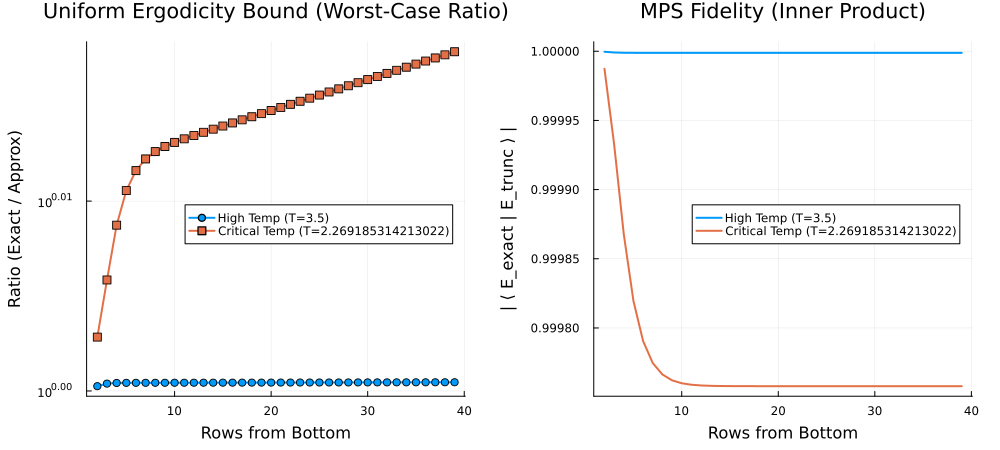

In [19]:
Lx = 40        
D_bound = 2     
Ly = 8

# High Temp (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temp (diverging Correlation Length)
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_high, fid_high, ratios_high = run_error_tracker(Lx, beta_high, D_bound; Ly=Ly)
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

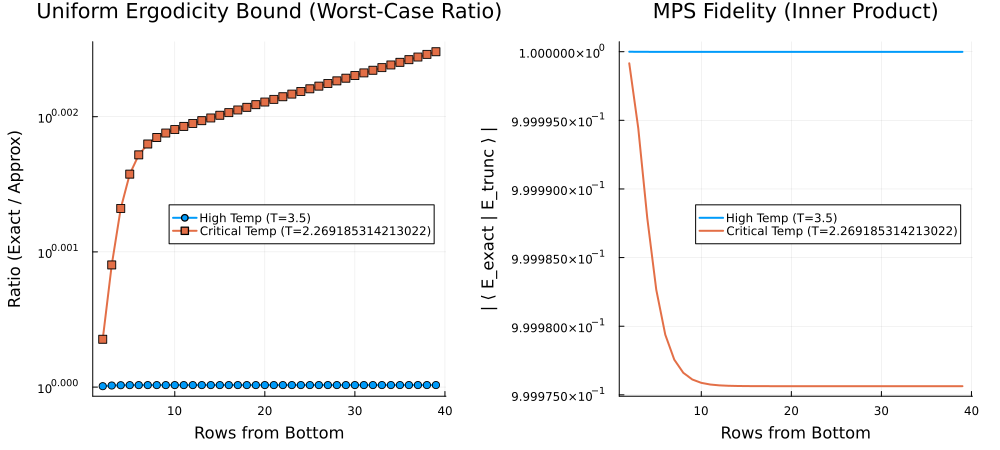

In [23]:
Lx = 40        
D_bound = 3     
Ly = 8

# High Temp (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temp (diverging Correlation Length)
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_high, fid_high, ratios_high = run_error_tracker(Lx, beta_high, D_bound; Ly=Ly)
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

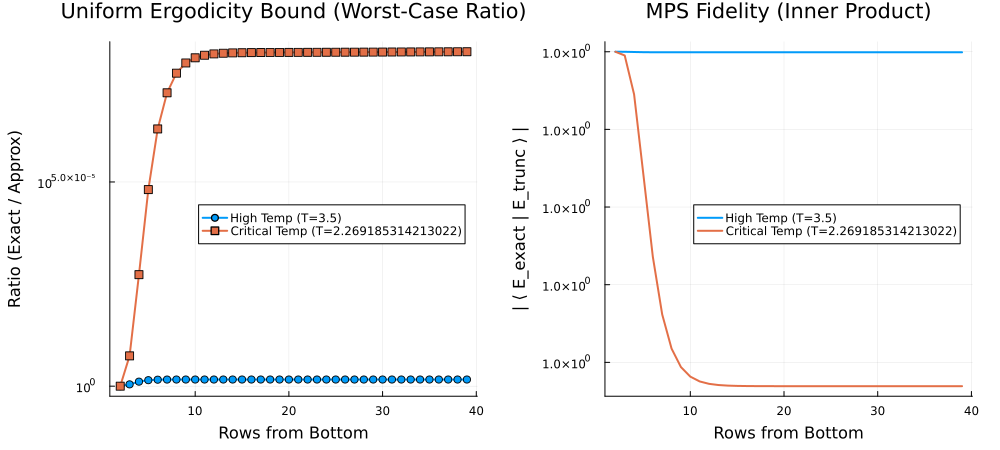

In [20]:
Lx = 40        
D_bound = 4     
Ly = 8

# High Temp (Disordered Phase)
T_high = 3.5
beta_high = 1.0 / T_high

# Critical Temp (diverging Correlation Length)
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_high, fid_high, ratios_high = run_error_tracker(Lx, beta_high, D_bound; Ly=Ly)
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_high, ratios_high, label="High Temp (T=$T_high)", linewidth=2, marker=:circle)
plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp (T=$T_crit)", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_high, fid_high, label="High Temp (T=$T_high)", linewidth=2)
plot!(pB, x_vals_crit, fid_crit, label="Critical Temp (T=$T_crit)", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

Now let's see what happens for a wider strip $L_y$:
- $L_y = 10 \Rightarrow D_{exact} = 32$
- $L_y = 12 \Rightarrow D_{exact} = 64$

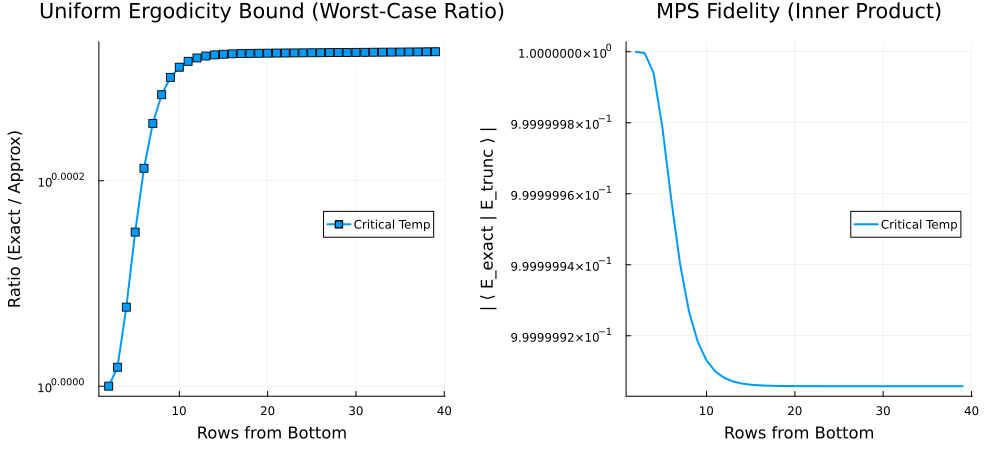

In [34]:
Lx = 40        
D_bound = 4     
Ly = 10

# Critical Temp
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_crit, fid_crit, label="Critical Temp", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

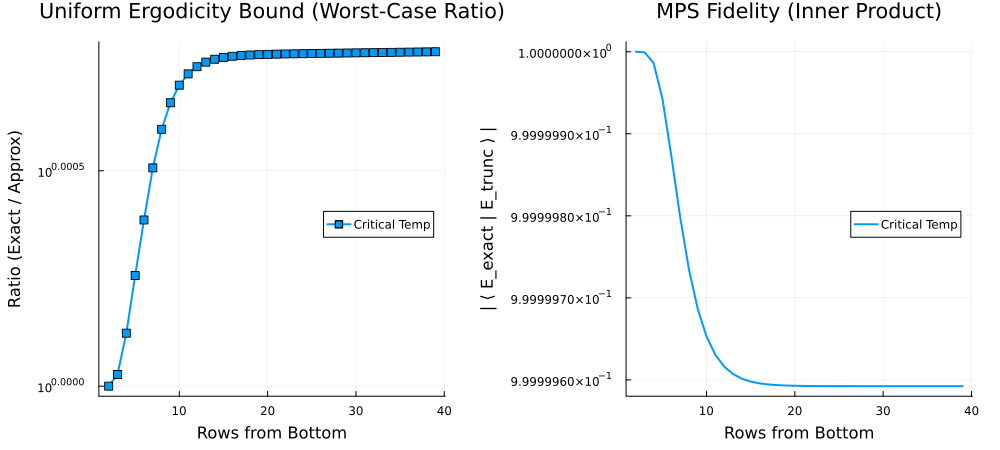

In [33]:
Lx = 40        
D_bound = 4     
Ly = 12

# Critical Temp
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_crit, fid_crit, label="Critical Temp", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

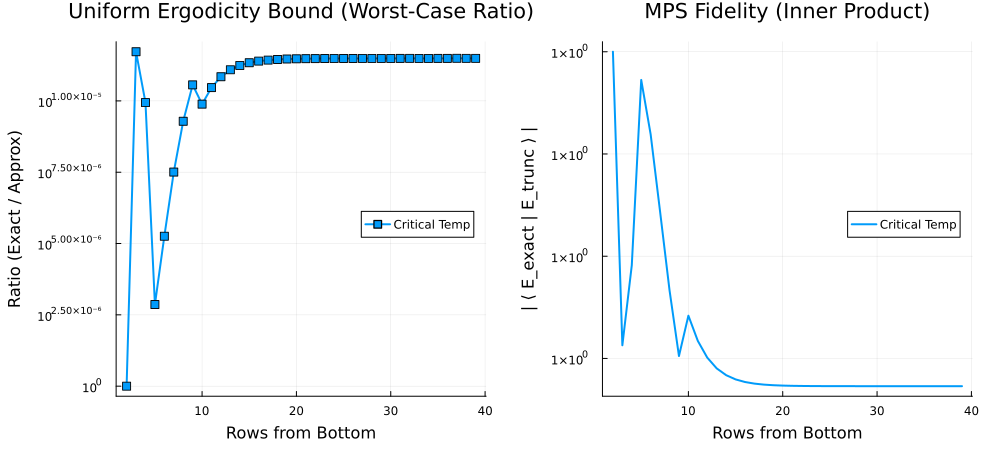

In [32]:
Lx = 40        
D_bound = 12     
Ly = 12

# Critical Temp
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_crit, fid_crit, label="Critical Temp", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

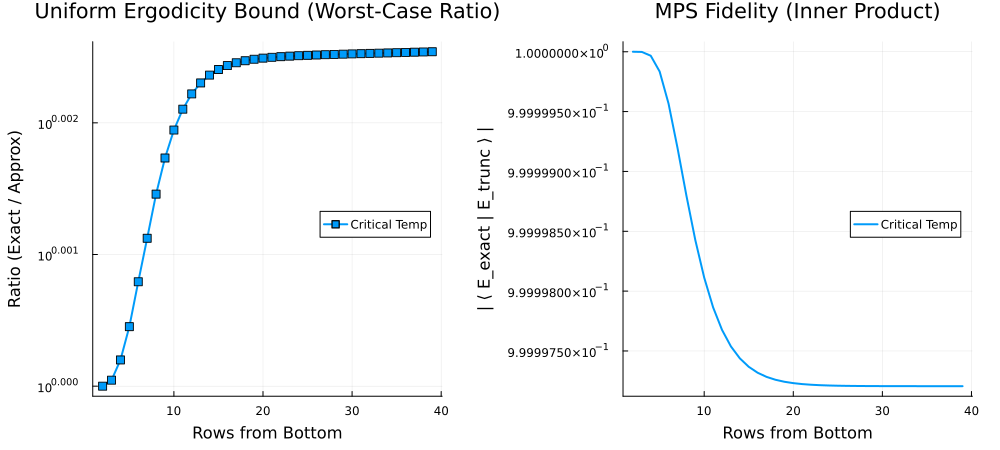

In [37]:
Lx = 40        
D_bound = 4     
Ly = 16

# Critical Temp
T_crit = 2 / log(1 + sqrt(2))
beta_crit = 1.0 / T_crit

# Run simulations
x_vals_crit, fid_crit, ratios_crit = run_error_tracker(Lx, beta_crit, D_bound; Ly=Ly)

# Plotting

# Left: The Mengersen-Tweedie Worst-Case Ratio ("C")
pA = plot(title="Uniform Ergodicity Bound (Worst-Case Ratio)", xlabel="Rows from Bottom", ylabel="Ratio (Exact / Approx)", yscale=:log10, legend=:right, grid=true)

plot!(pA, x_vals_crit, ratios_crit, label="Critical Temp", linewidth=2, marker=:square)

# Right: Additive Error (Fidelity)
pB = plot(title="MPS Fidelity (Inner Product)", xlabel="Rows from Bottom", ylabel="| ⟨ E_exact | E_trunc ⟩ |", legend=:right, grid=true)

plot!(pB, x_vals_crit, fid_crit, label="Critical Temp", linewidth=2)

plot(pA, pB, layout=(1, 2), size=(1000, 450), margin=5Plots.mm)

By tracking the Mengersen-Tweedie constant $C = \max [\pi / \tilde{\pi}_D]$ row-by-row, we observed that for $L_y = 8$, the ratio plateaus to a finite constant. This is a computational proof of Uniform Ergodicity. It mathematically guarantees that for this specific strip width, the correlation time of the TNMH algorithm is strictly bounded ($\tau_{corr} \le C$), and perfect sampling via Coupling From The Past (CFTP) is viable.

---

While $D=4$ achieves a plateau for $L_y=8$, $L_y=10$, and $L_y=12$, the actual numerical value of $C$ increases each time the strip gets wider (and decreases as we make $D_{bound}$ bigger). This happens because of a fundamental limit in Tensor Network physics: The Entanglement Deficit.

At the critical point $T_c$, the exact correlation length of the Ising model diverges. The entanglement entropy $S$ across the horizontal cut of the system grows logarithmically with the width of the system:

$$S_{exact} \propto \frac{c}{3} \log(L_y)$$

However, a Tensor Network with a maximum bond dimension $D_{bound}$ has a rigid, hardcoded maximum entropy capacity:

$$S_{capacity} = \log(D_{bound})$$

If we hold $D_{bound}$ constant while making $L_y$ wider, the exact critical state demands more entanglement than the tensor network can physically store. During the SVD step, the .compress() function is forced to throw away larger and larger singular values. As we discard more of the true physics, the proposal distribution diverges further from the exact Boltzmann distribution, forcing the worst-case error ratio $C$ to climb.

---

The Mengersen-Tweedie bound is highly punitive because it relies on the absolute maximum error ($\max_{x \in \Omega}$). Finding even one highly-entangled, rare spin configuration that the tensor network misrepresents will cause $C$ to skyrocket.

If we plot $\log(C)$ against $L_y$, we expect to see a straight line. This would empirically prove Exponential Volume Scaling:$$C(L_y) \propto \exp(\alpha L_y)$$If the mixing time bound scales exponentially with the system width, the bound becomes mathematically useless for calculating the thermodynamic limit of a 2D plane.

In [3]:
function compute_asymptotic_C(Lx::Int, Ly::Int, beta::Float64, D_bound::Int)
    A, s_inds, v_inds = create_ising_peps(Lx, Ly, beta, 1.0)
    b = [Index(2, "Site,b=$y") for y in 1:Ly]
    
    # Initialize environments
    tensors_Lx = ITensor[]
    for y in 1:Ly
        T_traced = A[Lx, y] * ITensor([1.0, 1.0], s_inds[Lx, y])
        T_traced = replaceinds(T_traced, [v_inds[Lx-1, y]] => [b[y]])
        push!(tensors_Lx, T_traced)
    end
    
    E_exact = MPS(tensors_Lx)
    E_trunc = MPS(tensors_Lx)
    log_Z_exact = 0.0
    log_Z_trunc = 0.0
    
    # Safe maxdim to guarantee exact representation for Ly
    exact_maxdim = 2^(Ly) 
    
    # Phase A: Sweep to build the saturated environment (NO inner loops here)
    for x in Lx-1:-1:2
        tensors_mpo = ITensor[]
        for y in 1:Ly
            T_traced = A[x, y] * ITensor([1.0, 1.0], s_inds[x, y])
            T_traced = replaceinds(T_traced, [v_inds[x, y], v_inds[x-1, y]] => [b[y], b[y]'])
            push!(tensors_mpo, T_traced)
        end
        MPO_x = MPO(tensors_mpo)
        
        # Exact Update
        E_exact = apply(MPO_x, E_exact; maxdim=exact_maxdim, cutoff=1e-15)
        E_exact = noprime(E_exact)
        orthogonalize!(E_exact, 1) 
        n_exact = norm(E_exact[1])
        E_exact[1] ./= n_exact
        log_Z_exact += log(n_exact)
        
        # Truncated Update
        E_trunc = apply(MPO_x, E_trunc; maxdim=D_bound, cutoff=1e-10)
        E_trunc = noprime(E_trunc)
        orthogonalize!(E_trunc, 1)
        n_trunc = norm(E_trunc[1])
        E_trunc[1] ./= n_trunc
        log_Z_trunc += log(n_trunc)
    end
    
    # Phase B: The Brute Force Measurement (Only done ONCE at the top row)
    max_ratio = 0.0
    x = 2 # The top row
    
    for i in 0 : (2^Ly - 1)
        spins = [(i >> (j - 1)) & 1 for j in 1:Ly]
        
        row_tensors_exact = ITensor[]
        row_tensors_trunc = ITensor[]
        
        for y in 1:Ly
            T = A[x-1, y] # This is A[1, y], the absolute top boundary
            state_vec = spins[y] == 0 ? [1.0, 0.0] : [0.0, 1.0]
            T *= ITensor(state_vec, s_inds[x-1, y])
            
            # Since we are at the top row (x-1 = 1), there is no upward vertical 
            # bond to trace out. The geometry handles this automatically.
            
            T_exact = T * replaceinds(E_exact[y], b[y] => v_inds[x-1, y])
            T_trunc = T * replaceinds(E_trunc[y], b[y] => v_inds[x-1, y])
            
            push!(row_tensors_exact, T_exact)
            push!(row_tensors_trunc, T_trunc)
        end
        
        prob_exact = abs(scalar(reduce(*, row_tensors_exact)))
        prob_trunc = abs(scalar(reduce(*, row_tensors_trunc)))
        
        if prob_trunc > 1e-30 && prob_exact > 1e-30
            log_prob_exact = log(prob_exact) + log_Z_exact
            log_prob_trunc = log(prob_trunc) + log_Z_trunc
            
            current_ratio = exp(log_prob_exact - log_prob_trunc)
            
            if current_ratio > max_ratio
                max_ratio = current_ratio
            end
        end
    end
    
    return max_ratio
end

compute_asymptotic_C (generic function with 1 method)

Starting Volume Scaling Experiment at Critical Temperature...
Simulating Ly = 4, D = 2...
Simulating Ly = 4, D = 3...
Simulating Ly = 4, D = 4...
Simulating Ly = 6, D = 2...
Simulating Ly = 6, D = 3...
Simulating Ly = 6, D = 4...
Simulating Ly = 8, D = 2...
Simulating Ly = 8, D = 3...
Simulating Ly = 8, D = 4...
Simulating Ly = 10, D = 2...
Simulating Ly = 10, D = 3...
Simulating Ly = 10, D = 4...
Simulating Ly = 12, D = 2...
Simulating Ly = 12, D = 3...
Simulating Ly = 12, D = 4...
Simulating Ly = 14, D = 2...
Simulating Ly = 14, D = 3...
Simulating Ly = 14, D = 4...
Simulating Ly = 16, D = 2...
Simulating Ly = 16, D = 3...
Simulating Ly = 16, D = 4...
Simulating Ly = 18, D = 2...
Simulating Ly = 18, D = 3...
Simulating Ly = 18, D = 4...
Simulating Ly = 20, D = 2...
Simulating Ly = 20, D = 3...
Simulating Ly = 20, D = 4...


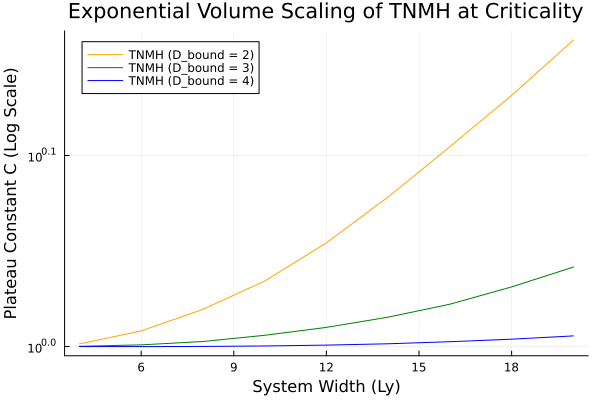

In [ ]:
Lx_fixed = 50
T_crit = 2.269
beta_crit = 1.0 / T_crit

# We sweep the width of the system
Ly_array = [4, 6, 8, 10, 12, 14, 16, 18, 20]

C_plateaus_D2 = Float64[]
C_plateaus_D3 = Float64[]
C_plateaus_D4 = Float64[]

println("Starting Volume Scaling Experiment at Critical Temperature...")

for Ly in Ly_array
    println("Simulating Ly = $Ly, D = 2...")
    C_D2 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 2)
    push!(C_plateaus_D2, C_D2)

    println("Simulating Ly = $Ly, D = 3...")
    C_D3 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 3)
    push!(C_plateaus_D3, C_D3)

    println("Simulating Ly = $Ly, D = 4...")
    C_D4 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 4)
    push!(C_plateaus_D4, C_D4)
end

# 3. Plotting the Exponential Explosion
# By plotting with yscale=:log10, an exponential function will appear as a straight line.
p = plot(title="Exponential Volume Scaling of TNMH at Criticality",
         xlabel="System Width (Ly)",
         ylabel="Plateau Constant C (Log Scale)",
         yscale=:log10,
         legend=:topleft,
         grid=true,
         marker=:circle,
         linewidth=2)

plot!(p, Ly_array, C_plateaus_D2, label="TNMH (D_bound = 2)", color=:orange)
plot!(p, Ly_array, C_plateaus_D3, label="TNMH (D_bound = 3)", color=:green)
plot!(p, Ly_array, C_plateaus_D4, label="TNMH (D_bound = 4)", color=:blue)

display(p)

In [ ]:
Lx_fixed = 50
T_crit = 2.269
beta_crit = 1.0 / T_crit

# We sweep the width of the system
Ly_array = [4, 8, 12, 16, 20, 24, 28, 32]

C_plateaus_D2 = Float64[]
C_plateaus_D3 = Float64[]
C_plateaus_D4 = Float64[]

println("Starting Volume Scaling Experiment at Critical Temperature...")

for Ly in Ly_array
    println("Simulating Ly = $Ly, D = 2...")
    C_D2 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 2)
    push!(C_plateaus_D2, C_D2)

    println("Simulating Ly = $Ly, D = 3...")
    C_D3 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 3)
    push!(C_plateaus_D3, C_D3)

    println("Simulating Ly = $Ly, D = 4...")
    C_D4 = compute_asymptotic_C(Lx_fixed, Ly, beta_crit, 4)
    push!(C_plateaus_D4, C_D4)
end

# 3. Plotting the Exponential Explosion
# By plotting with yscale=:log10, an exponential function will appear as a straight line.
p = plot(title="Exponential Volume Scaling of TNMH at Criticality",
         xlabel="System Width (Ly)",
         ylabel="Plateau Constant C (Log Scale)",
         yscale=:log10,
         legend=:topleft,
         grid=true,
         marker=:circle,
         linewidth=2)

plot!(p, Ly_array, C_plateaus_D2, label="TNMH (D_bound = 2)", color=:orange)
plot!(p, Ly_array, C_plateaus_D3, label="TNMH (D_bound = 3)", color=:green)
plot!(p, Ly_array, C_plateaus_D4, label="TNMH (D_bound = 4)", color=:blue)

display(p)

Starting Volume Scaling Experiment at Critical Temperature...
Simulating Ly = 4, D = 2...
Simulating Ly = 4, D = 3...
Simulating Ly = 4, D = 4...
Simulating Ly = 8, D = 2...
Simulating Ly = 8, D = 3...
Simulating Ly = 8, D = 4...
Simulating Ly = 12, D = 2...
Simulating Ly = 12, D = 3...
Simulating Ly = 12, D = 4...
Simulating Ly = 16, D = 2...
Simulating Ly = 16, D = 3...
Simulating Ly = 16, D = 4...
Simulating Ly = 20, D = 2...
Simulating Ly = 20, D = 3...
Simulating Ly = 20, D = 4...


At criticality, the plateauing of $C$ for $D=4$ is a finite-size sanctuary. The infinite correlation length is being artificially capped by the bond dimension ($\xi_D \propto D^\kappa$). As long as the strip width $L_y$ is smaller than $\xi_D$, the error remains bounded. But in the thermodynamic limit ($L_y \to \infty$), any finite $D$ will eventually trigger exponential volume scaling.